# 12-State HMM — TINDA
### OPM-MEG dataset collected by Rob 

In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

from osl_dynamics.data import Data
from osl_dynamics.models.hmm import Config, Model

# Anchor all relative paths to the project root so the notebook runs from anywhere
base_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data"
os.chdir(base_dir)

# Additional directories

model_dir = "results/12_states/model_12_states"
home_dir  = f"{base_dir}/results/12_states"
tinda_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi"
os.makedirs(tinda_dir, exist_ok=True)

data_location = "/ohba/pi/mwoolrich/rseymour/for_manu"

2026-07-27 13:40:34.771010: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-27 13:40:34.870503: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 13:40:35.745660: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 13:40:36.133418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785156036.522672  969289 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785156036.62

## Load and prepare the data

In [ ]:
# Find the resting-state (FLIPPED) recordings used to train the model
rs_files = sorted(glob.glob(f"{data_location}/*task-rest_run*FLIPPED-raw.fif"))
print("Total files:", len(rs_files))

# Prepare the data: TDE-PCA then standardize
data = Data(rs_files, picks="mag", reject_by_annotation="omit", n_jobs=3, sampling_frequency=250)
data.tde_pca(n_embeddings=15, n_pca_components=120)
data.standardize()

Total files: 74


QUEUEING TASKS | Loading files:   0%|          | 0/74 [00:00<?, ?it/s]

PROCESSING TASKS | Loading files:   0%|          | 0/74 [00:00<?, ?it/s]

    Range : 923 ... 73423 =      3.692 ...   293.692 secs
Ready.


COLLECTING RESULTS | Loading files:   0%|          | 0/74 [00:00<?, ?it/s]

...

PROCESSING TASKS | TDE-PCA:   0%|          | 0/74 [00:00<?, ?it/s]

COLLECTING RESULTS | TDE-PCA:   0%|          | 0/74 [00:00<?, ?it/s]

QUEUEING TASKS | Standardize:   0%|          | 0/74 [00:00<?, ?it/s]

PROCESSING TASKS | Standardize:   0%|          | 0/74 [00:00<?, ?it/s]

COLLECTING RESULTS | Standardize:   0%|          | 0/74 [00:00<?, ?it/s]

## Set up and run the 12-state HMM

In [ ]:
from osl_dynamics.models.hmm import Config, Model

# Configure the 12-state HMM (matches results/12_states/model_12_states/config.yml)
config = Config(
    n_states=12,                    # Number of hidden brain states to infer
    n_channels=data.n_channels,     # Input dimensionality (matches preprocessed data)
    sequence_length=300,            # Number of timepoints per training sequence/batch segment
    learn_means=False,              # Fix state means to zero
    learn_covariances=True,         # Allow each state to learn its own covariance structure
    batch_size=128,                 # Number of sequences processed per gradient update
    learning_rate=0.01,             # Step size for the Adam optimiser
    n_epochs=20,                    # Number of full passes through the training data
)

# Instantiate the HMM model with the specified configuration
model = Model(config)

In [ ]:
# THIS STEP TAKES AROUND 8 HOURS

# Initialise by randomly sampling state time courses across 3 trials (1 epoch each),
# keeping the best starting parameters to avoid poor local minima
init_history = model.random_state_time_course_initialization(data, n_init=3, n_epochs=1)

# Train the HMM on the full dataset, returning the loss history for monitoring convergence
history = model.fit(data)

import os

os.makedirs("results/12_states", exist_ok=True)
model.save(model_dir)

### Post-HMM: save inferred parameters

In [ ]:
import numpy as np
import os
import pickle

# Safety net: (re)load the trained 12-state model
model = Model.load(model_dir)

# Directory to store inferred model parameters
inf_params_dir = "results/12_states/inf_params"
os.makedirs(inf_params_dir, exist_ok=True)  

def save_model_params(model, data, prefix):   # this is what tinda analyses
    """
    Extract and save all inferred parameters from a trained HMM model.

    Args:
        model: Trained HMM model object
        data:  Input data used for inference (e.g. MEG/fMRI time series)
        prefix: String prefix for naming the output files (e.g. "model")

    Returns:
        alpha: State probability time courses (n_samples x n_states)
    """
    # State probability time courses — probability of being in each state at each time point
    alpha = model.get_alpha(data)

    # Inferred observation model parameters
    means = model.get_means()                   # Mean of Gaussian emission per state
    covs = model.get_covariances()              # Covariance matrices per state

    # Inferred HMM dynamics parameters
    trans_prob = model.get_trans_prob()                     # Transition probability matrix
    initial_state_probs = model.get_initial_state_probs()   # Initial state distribution

    # Save alpha as pickle (preserves any non-array structure)
    pickle.dump(alpha, open(f"{inf_params_dir}/{prefix}_alp.pkl", "wb"))

    # Save remaining parameters as .npy arrays
    np.save(f"{inf_params_dir}/{prefix}_means.npy", means)
    np.save(f"{inf_params_dir}/{prefix}_covs.npy", covs)
    np.save(f"{inf_params_dir}/{prefix}_trans_prob.npy", trans_prob)
    np.save(f"{inf_params_dir}/{prefix}_initial_state_probs.npy", initial_state_probs)

    return alpha

# Extract and persist all inferred parameters; alpha is returned for downstream analysis
alpha = save_model_params(model, data, "model")

2026-07-01 15:45:50 INFO osl-dynamics [mod_base.py:798:load]: Loading model: results/12_states/model_12_states


Getting alpha:   0%|          | 0/74 [00:00<?, ?it/s]

2026-07-01 15:45:55.112336: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:45:56.079777: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:45:57.587005: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:46:01.013423: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:46:07.811871: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:46:21.974430: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-01 15:46:52.278722: I tensorflow/core/framework/local_rendezvous.cc:407] L

## Viterbi state time courses

In [ ]:
from osl_dynamics.utils import plotting

# Safety net: (re)load the trained 12-state model
model = Model.load(model_dir)

# Viterbi path = single most likely hidden-state sequence per session.
# IMPORTANT: get_viterbi_path already returns ONE-HOT arrays of shape
# (n_samples, n_states), so the result can be passed straight to tinda()
# (no modes.argmax_time_courses needed, unlike the alpha-based version).

stc = model.get_viterbi_path(data)

print("n_sessions:", len(stc))
print("example session shape:", stc[0].shape)  # (n_samples, 12)

# Persist the viterbi state time courses so downstream cells can reload them
os.makedirs(tinda_dir, exist_ok=True)
np.savez(f"{tinda_dir}/stc_viterbi.npz", *stc)

# Quick sanity-check plot: first 2000 timepoints (~8 s at 250 Hz) of session 0
plotting.plot_alpha(stc[0], n_samples=2000, sampling_frequency=250)
plt.show()

# COMPUTE PSD #

In [ ]:
"""
Load model outputs, trim the data, and compute multitaper spectra.
"""

import numpy as np
import pickle
import os
from osl_dynamics.data import Data
from osl_dynamics.analysis import spectral

# Load MEG dataset (raw sensor data for spectral estimation)
data = Data(rs_files, picks="mag", reject_by_annotation="omit", n_jobs=3)

# Safety net: load the saved soft state probabilities (alpha)
alpha = pickle.load(open("results/12_states/inf_params/model_alp.pkl", "rb"))

# Trim the data (must match the embedding + sequence length used at training time).
# NOTE: this 12-state model was trained with sequence_length=300, so we trim with 300
# (the alpha returned by get_alpha is aligned to sequences of length 300).
trimmed_data = data.trim_time_series(n_embeddings=15, sequence_length=300)

# Print shapes to check alignment of alpha and data
print("Shapes:")
for a, x in zip(alpha, trimmed_data):
    print(a.shape, x.shape)

# Compute multitaper spectra
print("\nComputing multitaper spectra...")
f, psd, coh, w = spectral.multitaper_spectra(
    data=trimmed_data,
    alpha=alpha,
    sampling_frequency=250,
    frequency_range=[2, 45],
    return_weights=True,
)

# Save spectra results
os.makedirs("results/12_states/spectra", exist_ok=True)

np.save("results/12_states/spectra/f.npy", f)
np.save("results/12_states/spectra/psd.npy", psd)
np.save("results/12_states/spectra/coh.npy", coh)
np.save("results/12_states/spectra/w.npy", w)

print("\nDone! Spectral results saved in results/12_states/spectra/")

# Relabel state labels from highest to lowest power 

In [ ]:
import os, pickle, shutil
import numpy as np
from osl_dynamics.analysis import power

relabel_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states"

# 1. Determine the power ordering (highest -> lowest), same measure as maps

psd = np.load(f"{relabel_dir}/spectra/psd.npy")   # (n_subj, n_states, n_chan, n_freq)
f   = np.load(f"{relabel_dir}/spectra/f.npy")
w   = np.load(f"{relabel_dir}/spectra/w.npy")

p = power.variance_from_spectra(f, psd)                       # (n_subj, n_states, n_channels)
power_per_state = np.average(p, axis=0, weights=w).mean(-1)   # (n_states,)
order = np.argsort(power_per_state)[::-1]                     # new->old
inv   = np.argsort(order)                                     # old->new (for remapping id lists)

# Idempotency guard: if psd is already power-sorted, order == identity -> no-op
if np.array_equal(order, np.arange(len(order))):
    print("Already relabelled by power — nothing to do.")
else:
    print("power per state:", np.round(power_per_state, 4))
    print("new state -> old state:", {i + 1: int(o) for i, o in enumerate(order)})

    # Track outcomes so we can report skipped files at the end
    reordered_files = []
    missing_files   = []

    def backup(fp):
        if os.path.exists(fp) and not os.path.exists(fp + ".preorder"):
            shutil.copy2(fp, fp + ".preorder")

    def reorder_npy(rel, fn):
        fp = f"{relabel_dir}/{rel}"
        if not os.path.exists(fp):
            print("skip (missing):", rel); missing_files.append(rel); return
        backup(fp); np.save(fp, fn(np.load(fp))); print("reordered", rel)
        reordered_files.append(rel)

    def reorder_pkl(rel, fn):
        fp = f"{relabel_dir}/{rel}"
        if not os.path.exists(fp):
            print("skip (missing):", rel); missing_files.append(rel); return
        backup(fp)
        with open(fp, "rb") as fh: obj = pickle.load(fh)
        with open(fp, "wb") as fh: pickle.dump(fn(obj), fh)
        print("reordered", rel)
        reordered_files.append(rel)

    def reorder_npz(rel):
        fp = f"{relabel_dir}/{rel}"
        if not os.path.exists(fp):
            print("skip (missing):", rel); missing_files.append(rel); return
        backup(fp)
        d = np.load(fp, allow_pickle=True)
        arrs = [d[f"arr_{i}"][:, order] for i in range(len(d.files))]
        np.savez(fp, *arrs); print("reordered", rel)
        reordered_files.append(rel)

    # spectra
    reorder_npy("spectra/psd.npy",       lambda a: a[:, order])
    reorder_npy("spectra/coh.npy",       lambda a: a[:, order])
    reorder_npy("spectra/model_gfo.npy", lambda a: a[order])
    reorder_pkl("spectra/model_fo.pkl",  lambda a: a[:, order])
    # inferred params
    reorder_npy("inf_params/model_means.npy",               lambda a: a[order])
    reorder_npy("inf_params/model_covs.npy",                lambda a: a[order])
    reorder_npy("inf_params/model_initial_state_probs.npy", lambda a: a[order])
    reorder_npy("inf_params/model_trans_prob.npy",          lambda a: a[np.ix_(order, order)])
    reorder_pkl("inf_params/model_alp.pkl",                 lambda al: [a[:, order] for a in al])
    # state time courses
    reorder_npz("TINDA_viterbi/stc_viterbi.npz")
    reorder_npz("stc.npz")
    # cycle sequences: values are OLD state ids -> remap to new ids
    reorder_npy("best_sequence_group.npy",               lambda s: inv[s])
    reorder_npy("TINDA_viterbi/best_sequence_viterbi.npy", lambda s: inv[s])

    # summary
    
    print(f"\n=== Relabel summary ===")
    print(f"reordered ({len(reordered_files)}):")
    for rel in reordered_files:
        print(f"   ✓ {rel}")
    print(f"skipped — file did not exist ({len(missing_files)}):")
    for rel in missing_files:
        print(f"   ✗ {rel}")
    if not missing_files:
        print("   (none — every target file was present)")

    print("\nData files relabelled. Now regenerate the images (see below).")

### PLOTTING PSD GRAPHS ###

results/12_states/spectra/model: psd_mean shape = (12, 87)


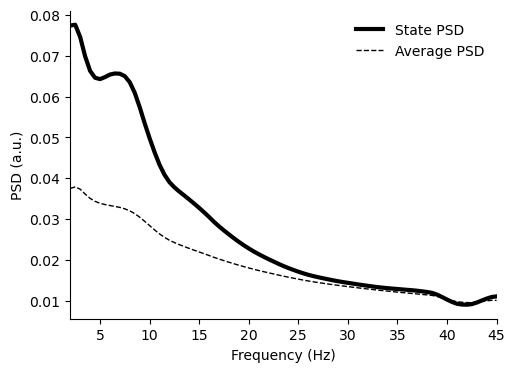

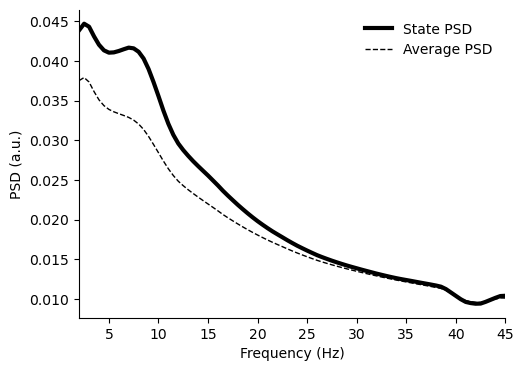

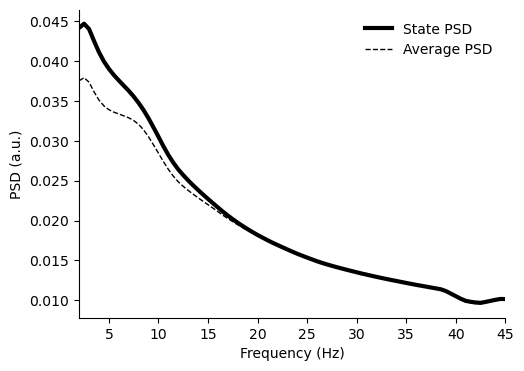

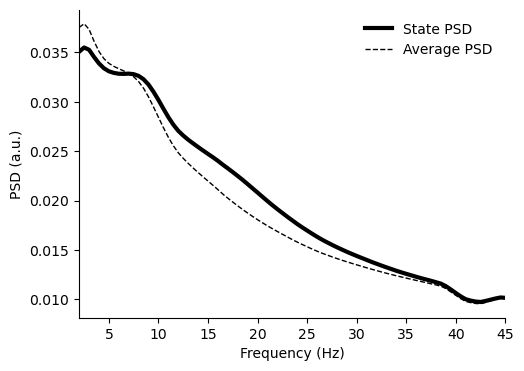

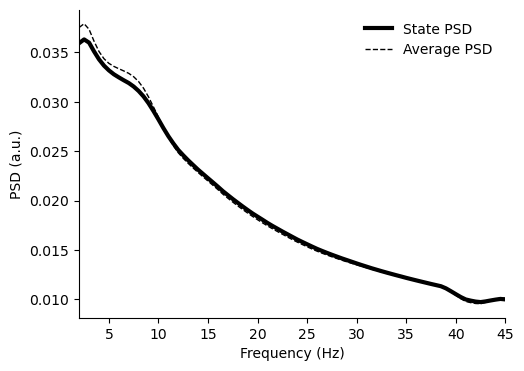

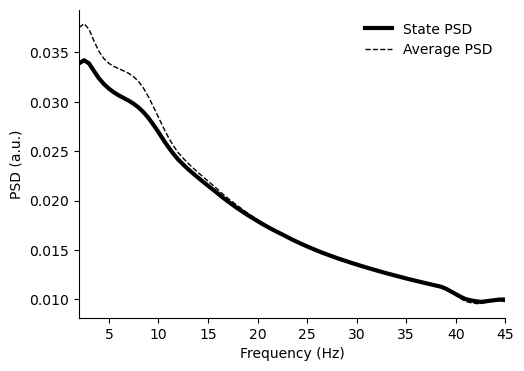

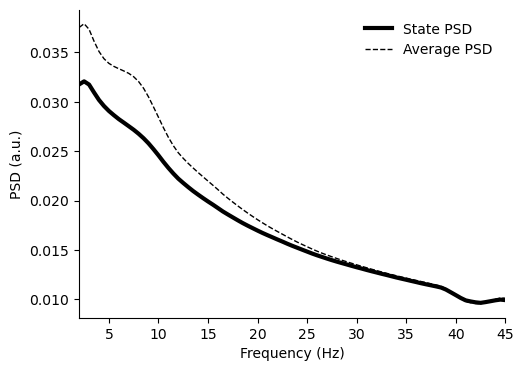

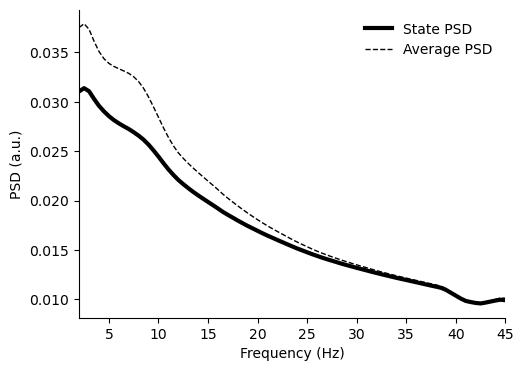

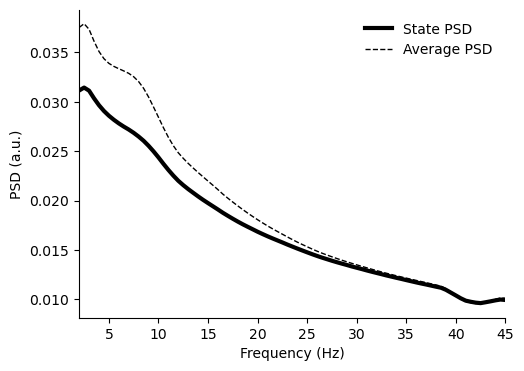

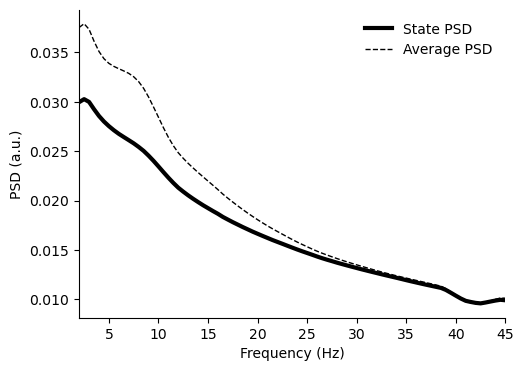

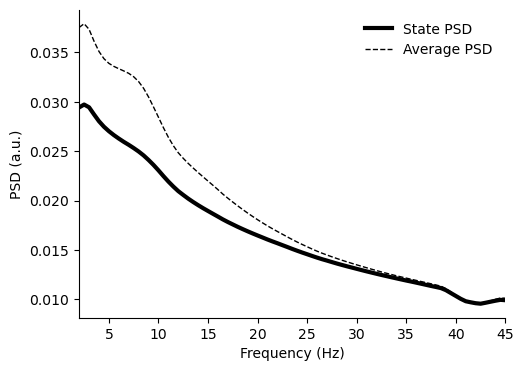

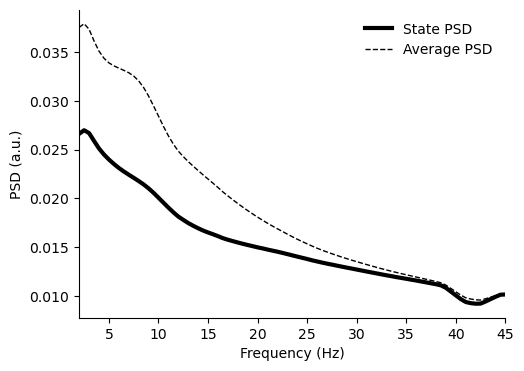

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from osl_dynamics.utils import plotting

# Safety net: load the saved spectra
psd = np.load("results/12_states/spectra/psd.npy")
w   = np.load("results/12_states/spectra/w.npy")
coh = np.load("results/12_states/spectra/coh.npy")
f   = np.load("results/12_states/spectra/f.npy")

def plot_state_psd(frequencies, psd, weights, prefix):
    """
    Compute group-averaged PSD and plot per-state PSDs with overall mean.
    Saves figures individually as PNG.
    """
    # Average over subjects and channels
    gpsd = np.average(psd, axis=0, weights=weights)   # (n_states, n_channels, n_freqs)
    psd_mean = np.mean(gpsd, axis=1)                  # (n_states, n_freqs)

    print(f"{prefix}: psd_mean shape = {psd_mean.shape}")

    overall_mean = np.mean(psd_mean, axis=0)
    n_states = psd_mean.shape[0]

    # Loop through states
    for i in range(n_states):
        fig, ax = plt.subplots(figsize=(5.5, 4))

        ax.plot(frequencies, psd_mean[i],
                linewidth=3, linestyle='-', color='black', label="State PSD")
        ax.plot(frequencies, overall_mean,
                linewidth=1, linestyle='--', color='black', label="Average PSD")

        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD (a.u.)")
        ax.set_xlim([frequencies[0], frequencies[-1]])

        ax.legend(frameon=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        fig.savefig(f"{prefix}_PSD_state_{i}.png", bbox_inches='tight')
        plt.show()
        # plt.close(fig)

# Plot and save PSDs
plot_state_psd(f, psd, w, prefix="results/12_states/spectra/model")

### NEOCORTICAL MAPS ###

In [ ]:
"""
Compute fractional occupancies, subtract weighted mean PSD, compute variance-based
power maps, and save results.
"""

from osl_dynamics.analysis import power
from osl_dynamics.inference import modes
import numpy as np
import pickle
import os

# Safety net: load the saved alpha and spectra
alpha = pickle.load(open("results/12_states/inf_params/model_alp.pkl", "rb"))
psd = np.load("results/12_states/spectra/psd.npy")
w   = np.load("results/12_states/spectra/w.npy")
f   = np.load("results/12_states/spectra/f.npy")

def process_model_results(alpha, psd, w, f, prefix):
    """
    Parameters
    ----------
    alpha : list of arrays
        Posterior state probabilities per subject.
    psd : ndarray
        Multitaper power spectral density: (n_subjects, n_states, n_channels, n_freqs)
    w : ndarray
        Weights for subjects for averaging, shape (n_subjects,).
    f : ndarray
        Frequency axis.
    prefix : str
        Prefix used when saving files.
    """

    print(f"\n--- Processing {prefix} ---")

    # Compute fractional occupancies for each subject and group average
    fo = np.array([modes.fractional_occupancies(a) for a in alpha])  # (n_subj, n_states)
    gfo = fo.mean(axis=0)                                            # (n_states,)
    print(f"{prefix} FO shape: {fo.shape}, group FO shape: {gfo.shape}")

    # Save FO results
    os.makedirs("results/12_states/spectra", exist_ok=True)
    np.save(f"results/12_states/spectra/{prefix}_gfo.npy", gfo)
    with open(f"results/12_states/spectra/{prefix}_fo.pkl", "wb") as f_out:
        pickle.dump(fo, f_out)

    # Subtract weighted mean across states (standard preprocessing step)
    psd = psd - np.average(psd, axis=1, weights=gfo, keepdims=True)

    # Group-average across subjects and channels
    gpsd = np.average(psd, axis=0, weights=w)        # (n_states, n_channels, n_freqs)
    psd_mean = np.mean(gpsd, axis=1)                 # (n_states, n_freqs)
    print(f"{prefix} PSD mean shape: {psd_mean.shape}")

    # Convert PSD to variance for power mapping
    p = power.variance_from_spectra(f, psd)
    p -= np.average(p, axis=1, weights=gfo, keepdims=True)
    p_mean = np.average(p, axis=0, weights=w)        # (n_channels,)
    print(f"{prefix} Power map shape: {p_mean.shape}")

    # Save power maps to surface plot
    os.makedirs("results/12_states/maps", exist_ok=True)

    power.save(
        p_mean,
        mask_file="MNI152_T1_8mm_brain.nii.gz",
        parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
        subtract_mean=False,
        component=0,
        filename=f"results/12_states/maps/{prefix}_states_HMM.png",
        plot_kwargs={
            "cmap": "Spectral_r",
            "symmetric_cbar": True,
            "views": ['lateral', 'medial'],
        },
    )

    print(f"{prefix} processing complete. Results saved to results/12_states/maps")

    return p_mean

# Run
psd_mean = process_model_results(alpha, psd, w, f, prefix="model")

# TINDA #

In [36]:
import os
import numpy as np
from matplotlib import pyplot as plt
from osl_dynamics.analysis.tinda import tinda, plot_cycle, optimise_sequence
from osl_dynamics.inference import modes

# Safety net: reload the viterbi state time courses from disk
stc_npz = np.load("/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/stc_viterbi_relabeled.npz", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]

fo_density, fo_sum, stats = tinda(stc)

# fo_density: proportion of time a state spends in a given half (first/second)
#   of the intervals between a reference state, averaged across intervals.
#   dim 0 = reference state, dim 1 = state whose FO is computed, dim 2 = interval half.
# fo_sum: total summed occupancy across intervals (not averaged).
# stats: per-state interval details (counts, durations, ...).

In [40]:
best_sequence = optimise_sequence(fo_density)
np.save(f"{tinda_dir}/best_sequence_relabeled.npz", best_sequence)

print(best_sequence)

/home/mricofernándezsansilvestre/miniforge3/envs/osld/lib/python3.12/site-packages/osl_dynamics/analysis/tinda.py:655: RuntimeWarning: invalid value encountered in divide
  temp = (fo_density[:, :, 0, :] - fo_density[:, :, 1, :]) / np.mean(
/home/mricofernándezsansilvestre/miniforge3/envs/osld/lib/python3.12/site-packages/osl_dynamics/analysis/tinda.py:661: RuntimeWarning: invalid value encountered in divide
  np.mean(fo_density[:, :, 0, :] - fo_density[:, :, 1, :], axis=2)


[ 0  3  7 10  9 11  6  8  2  4  1  5]


## FO asymmetry matrix reordered by the best-states sequence

/tmp/ipykernel_4021299/336866454.py:19: RuntimeWarning: Mean of empty slice
  np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]), axis=-1)
/tmp/ipykernel_4021299/336866454.py:28: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, _fo_pvals = ttest_rel(_fh, _sh, axis=-1, nan_policy="omit")


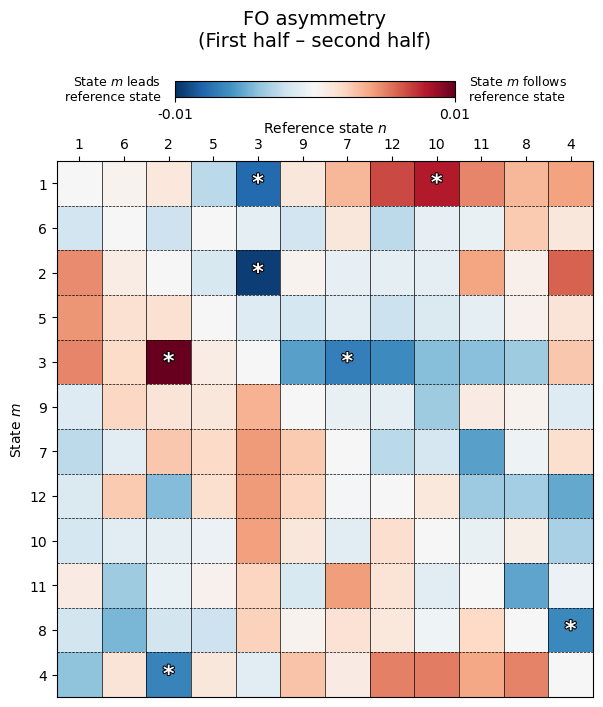

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import ttest_rel
from osl_dynamics.analysis.tinda import tinda

# 1. Define directory
tinda_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi"

# 2. Load best sequence and STC
best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")
stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]

# 3. Compute asymmetry matrix
fo_density, _, _ = tinda(stc)
mean_direction = np.squeeze(
    np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]), axis=-1)
)
mean_direction[np.isnan(mean_direction)] = 0

# 4. Significance matrix
_fh = fo_density[:, :, 0]; _sh = fo_density[:, :, 1]
if _fh.ndim == 4:
    _fh = _fh[:, :, 0, :]; _sh = _sh[:, :, 0, :]
with np.errstate(all="ignore"):
    _, _fo_pvals = ttest_rel(_fh, _sh, axis=-1, nan_policy="omit")
_fo_pvals = np.asarray(_fo_pvals, dtype=float); _fo_pvals[np.isnan(_fo_pvals)] = 1.0
_K = mean_direction.shape[0]
fo_sig = _fo_pvals < 0.05 / (_K * (_K - 1)); np.fill_diagonal(fo_sig, False)

# 5. Create the reversed cycle order (keeping state 0 at index 0)
best_seq_rev = np.roll(best_sequence[::-1], 1)

# 6. Reorder BOTH matrix and significance using best_seq_rev
mean_direction_reordered = mean_direction[best_seq_rev][:, best_seq_rev]
fo_sig_reordered = fo_sig[best_seq_rev][:, best_seq_rev]

# 6.b Transpose so COLUMNS = reference state n, ROWS = state m 
M = mean_direction_reordered.T
S = fo_sig_reordered.T

# 7. Plotting
fig, ax = plt.subplots(figsize=(8, 8))
n = mean_direction_reordered.shape[0]
# Symmetric limits so white == 0 (color = sign, not offset)
vlim = np.abs(M).max()

ax.imshow(M, cmap='RdBu_r', vmin=-vlim, vmax=vlim)

# Grid lines
for i in range(n + 1):
    ax.axhline(i - 0.5, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(i - 0.5, color='black', linewidth=0.5)

# Tick labels match best_seq_rev
ax.set_xticks(range(n))
ax.set_xticklabels(best_seq_rev + 1)
ax.set_yticks(range(n))
ax.set_yticklabels(best_seq_rev + 1)

# Move x-axis labels to top
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

ax.set_xlabel("Reference state $n$")        # columns = reference (true, after .T)
ax.set_ylabel("State $m$")                  # rows = m

# Colorbar  (RdBu_r: negative -> blue, positive -> red; no invert_xaxis)
cbar_ax = fig.add_axes([0.325, 0.86, 0.35, 0.02])
cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation='horizontal')

cbar.set_ticks([-vlim, vlim])
cbar.set_ticklabels([f"{-vlim:.2f}", f"{vlim:.2f}"])

cbar_ax.text(-0.05, 0.5, "State $m$ leads\nreference state", fontsize=9,
             transform=cbar_ax.transAxes, ha='right', va='center')   # left = blue = negative = leads
cbar_ax.text(1.05, 0.5, "State $m$ follows\nreference state", fontsize=9,
             transform=cbar_ax.transAxes, ha='left', va='center')    # right = red = positive = follows

fig.suptitle("FO asymmetry\n(First half – second half)", fontsize=14, y=0.97)
fig.subplots_adjust(top=0.78)

# Significance asterisks (use transposed S)
for _i in range(n):
    for _j in range(n):
        if S[_i, _j]:
            ax.text(_j, _i, "*", ha="center", va="center", color="white",
                    fontsize=16, fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])

os.makedirs(tinda_dir, exist_ok=True)
plt.savefig(f"{tinda_dir}/fo_asymmetry_reordered_viterbi.png", dpi=150, bbox_inches='tight')
plt.show()

In [58]:
perc = 0.25
n_largest = int((np.prod(mean_direction.shape) - mean_direction.shape[0]) * perc)
largest_indices = np.abs(mean_direction).argsort(axis=None)[-n_largest:]
strongest_edges = np.zeros(mean_direction.shape)
strongest_edges[np.unravel_index(largest_indices, mean_direction.shape)] = 1

In [ ]:
plot_cycle(best_sequence, fo_density, strongest_edges, new_figure=True)
plt.savefig(f"{tinda_dir}/cycle_viterbi.png")
plt.show()

In [4]:
stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]

## Summary metrics (FO / LT / IT / State visits)

In [10]:
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc


# Safety net: reload viterbi state time courses
stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]

# The four summary metrics
fo = modes.fractional_occupancies(stc)                         # FO
lt = modes.mean_lifetimes(stc, sampling_frequency=250)         # LT (seconds)
it = modes.mean_intervals(stc, sampling_frequency=250)         # IT (seconds)

# Number of state visits, capitalising on state_activations function of post_hoc.py
def n_state_visits(stc):
    """Number of visits (activations) to each state, per session.

    stc : list of (n_samples, n_states) one-hot arrays (or a single array).
    returns : (n_sessions, n_states) int array.
    """
    acts = post_hoc.state_activations(stc)                       # [session][state] -> list of slices
    return np.array([[len(state_slices) for state_slices in session]
                     for session in acts])
                     
visits = n_state_visits(stc)                            # (n_sessions, n_states)         
fs = 250                                                # sampling frequency
lengths = np.array([s.shape[0] for s in stc])           # samples per session
svs_per_second = visits / (lengths[:, None] / fs)       # visits per second, shape: (74,12)

# Each has shape (n_subjects, n_states)
print("FO:", fo.shape)
print("LT:", lt.shape)
print("IT:", it.shape)
print("SVs:", svs_per_second.shape)

FO: (74, 12)
LT: (74, 12)
IT: (74, 12)
SVs: (74, 12)


In [11]:
import numpy as np

# Group averages per state
print("Mean FO per state:", np.mean(fo, axis=0))
print("Mean LT per state:", np.mean(lt, axis=0))
print("Mean IT per state:", np.mean(it, axis=0))
print("Mean State Visit Rate per state:", np.mean(svs_per_second, axis=0))

Mean FO per state: [0.02976827 0.0892262  0.09152401 0.07705166 0.0851173  0.07813758
 0.08628227 0.09341709 0.09148512 0.08547244 0.0875523  0.10496577]
Mean LT per state: [0.07753177 0.05012144 0.0438954  0.03930625 0.04055052 0.03899516
 0.04124015 0.04194211 0.04186573 0.041854   0.04269767 0.0557395 ]
Mean IT per state: [3.59016983 0.51671394 0.4478031  0.47588736 0.44985694 0.47239253
 0.44075773 0.4098667  0.41865305 0.44809647 0.445978   0.51879552]
Mean State Visit Rate per state: [0.3487426  1.77794552 2.07850686 1.96499221 2.09009603 1.99766851
 2.08949047 2.22521487 2.18476868 2.04222529 2.04946622 1.81348428]


In [13]:
from osl_dynamics.utils import plotting

plotting.plot_violin(fo.T, x_label="State", y_label="FO",
                     filename=f"{tinda_dir}/fo_violin_viterbi.png")
plotting.plot_violin(lt.T * 1000, x_label="State", y_label="LT (ms)",
                     filename=f"{tinda_dir}/lt_violin_viterbi.png")
plotting.plot_violin(it.T * 1000, x_label="State", y_label="IT (ms)",
                     filename=f"{tinda_dir}/it_violin_viterbi.png")
plotting.plot_violin(svs_per_second.T, x_label="State", y_label="Visits rate (Hz)",
                     filename=f"{tinda_dir}/state_visits_rate.png")

2026-07-27 12:23:51 INFO osl-dynamics [plotting.py:107:save]: Saving /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/fo_violin_viterbi.png
2026-07-27 12:23:51 INFO osl-dynamics [plotting.py:107:save]: Saving /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/lt_violin_viterbi.png
2026-07-27 12:23:51 INFO osl-dynamics [plotting.py:107:save]: Saving /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/it_violin_viterbi.png
2026-07-27 12:23:51 INFO osl-dynamics [plotting.py:107:save]: Saving /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/state_visits_rate.png


## Cycle duration (second-level HMM)

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from pathlib import Path

import statsmodels.formula.api as smf

from osl_dynamics.data import Data
from osl_dynamics.inference import modes
from osl_dynamics.models.hmm_poi import Config, Model
from osl_dynamics.analysis.tinda import tinda, plot_cycle, optimise_sequence

In [3]:
# Reload viterbi state time courses and best sequence

stc_load = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
stc_viterbi = [stc_load[f"arr_{i}"] for i in range(len(stc_load.files))]

best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")

hmm_dir = "results/12_states/secondlevel_hmm"
os.makedirs(hmm_dir, exist_ok=True)



In [10]:
def load_and_reorder_stc(W: int = 16):
    """Best cycle sequence based on group-optimalised sequence.
    The FO and FO timecourses (wdata) are also reordered
    according to this sequence."""
    # Load the saved (viterbi) stc from .npz
    stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
    stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]

    # assumes state time course is timepoints X states
    n_states = stc[0].shape[1]

    # Load best sequence with numpy instead of pickle (version conflict)
    best_sequence = np.load("/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/best_sequence_relabeled.npz.npy")

    # here we reorder state sequences
    stc_reorder = [istc[:, best_sequence] for istc in stc]

    # Calculate FOs (in the reordered sequence)
    fo = modes.fractional_occupancies(stc_reorder)

    # create windowed data (in the reordered sequence)
    wdata = []
    for i_stc in stc_reorder:
        n_times = i_stc.shape[0]
        i_data = np.zeros((n_times - W, n_states))
        for i in range(n_times - W):
            i_data[i, :] = np.sum(i_stc[i : i + W, :], axis=0)
        wdata.append(i_data)
    data = Data(wdata)

    return stc_reorder, data, fo, n_states

In [11]:
stc_reorder, data, fo, n_states = load_and_reorder_stc()

Loading files:   0%|          | 0/74 [00:00<?, ?it/s]

In [19]:
def run_second_level_hmm(
    data: Data = None,
    n_runs: int = 5,
    n_states: int = None,
    n_states_second_level: int = None,
    fs: int = 250,
):
    for i_run in range(n_runs):
        rundir = f"{hmm_dir}/run{i_run+1}"
        os.makedirs(rundir, exist_ok=True)

        # Because we reordered the states according to bestseq
        # we can use 1-K1 as bestseq
        seq = np.roll(np.arange(n_states).flatten(), 0)
        W_mean = init_log_rates(n_states, n_states_second_level, seq, fo.mean(axis=0))

        Pstructure = 0.99 * np.eye(n_states_second_level) + 0.01 * np.diag(
            np.ones((n_states_second_level - 1)), 1
        )
        Pstructure[-1, 0] = 0.01

        config = Config(
            n_states=n_states_second_level,
            n_channels=n_states,  # first level HMM states
            sequence_length=200,
            initial_trans_prob=Pstructure,
            initial_state_probs=np.ones(n_states_second_level) / n_states_second_level,
            learn_trans_prob=True,
            learn_log_rates=False,
            batch_size=1028,
            learning_rate=0.01,
            n_epochs=1,
            initial_log_rates=np.log(
                W_mean
            ),  # take the natural log (np.log) of the W_mean
        )
        model = Model(config)

        # Initialization and training
        init_history = model.random_state_time_course_initialization(
            data, n_init=3, n_epochs=1
        )
        history = model.fit(data)

        # Want the run with lowest free energy
        free_energy = model.free_energy(data)
        if i_run == 0 or free_energy < best_fe:
            best_fe = deepcopy(free_energy)
            run = i_run

        # State probabilities
        alp = model.get_alpha(data)
        pickle.dump(alp, open(f"{rundir}/alp.pkl", "wb"))

        # Calculate state time course
        viterbi_paths = []

        # Get fitted transition probability matrix
        trans_prob = model.get_trans_prob()
        initial_state_probs = model.get_initial_state_probs()

        for sp in alp:
            # Wrote my own viterbi path function due to version conflicts
            path = viterbi_from_posteriors(sp, trans_prob, initial_state_probs)
            viterbi_paths.append(path)

        # Save Viterbi paths
        pickle.dump(viterbi_paths, open(f"{rundir}/stc_2ndlevel.pkl", "wb"))

        cycle_duration = []
        cycle_rate = []

        for i_stc in viterbi_paths:
            # Get the initial dominant state (i.e., the first state in the path)
            dominant_state = i_stc[0]

            # Create binary vector: 1 when in the dominant state, 0 otherwise
            in_state = (i_stc == dominant_state).astype(int)

            # Detect transitions from the the dominant state
            transitions = np.diff(in_state)

            # Find end points of the dominant state (where it transitions out: 1 -> 0)
            ends = np.where(transitions == -1)[0]

            # Compute durations between each exit
            durations = (
                np.diff(np.insert(ends, 0, 0)) / fs
            )  # insert start at 0, then divide by sampling rate

            # Compute cycle rate (Hz)
            # Cycles per second over the full duration of the time course
            total_time_seconds = len(i_stc) / fs
            rate = len(ends) / total_time_seconds

            # Append to list
            cycle_duration.append(durations)
            cycle_rate.append(rate)

        # Save cycle duration and cycle rate
        pickle.dump(cycle_duration, open(f"{rundir}/cycle_duration.pkl", "wb"))
        pickle.dump(cycle_rate, open(f"{rundir}/cycle_rate.pkl", "wb"))

        # Save trained model
        model.save(f"{rundir}/model")

        # Save training history and free energy
        pickle.dump(init_history, open(f"{rundir}/init_history.pkl", "wb"))
        pickle.dump(history, open(f"{rundir}/history.pkl", "wb"))

        free_energy = model.free_energy(data)
        pickle.dump(free_energy, open(f"{rundir}/free_energy.pkl", "wb"))

        # Observation model parameters
        log_rates = model.get_log_rates()
        pickle.dump(log_rates, open(f"{rundir}/log_rates.pkl", "wb"))

    # ---> ADDED: Rename the folder for the run with lowest free energy <---
    best_run_num = run + 1
    old_dir = f"{hmm_dir}/run{best_run_num}"
    new_dir = f"{hmm_dir}/run{best_run_num}(lowest_fe)"

    if os.path.exists(old_dir):
        # Clean up existing lowest_fe folder if you are re-running in the same hmm_dir
        if os.path.exists(new_dir):
            import shutil
            shutil.rmtree(new_dir)
        os.rename(old_dir, new_dir)

    # ---> FIX: Load and return the arrays directly from the best run's folder <---
    target_dir = new_dir if os.path.exists(new_dir) else old_dir
    best_cycle_duration = pickle.load(open(f"{target_dir}/cycle_duration.pkl", "rb"))
    best_cycle_rate = pickle.load(open(f"{target_dir}/cycle_rate.pkl", "rb"))

    return best_cycle_duration, best_cycle_rate


In [20]:
def viterbi_from_posteriors(state_probs, trans_mat, init_probs):
    """
    Compute Viterbi path from state posterior probabilities and transition matrix.

    Args:
        state_probs: np.array (T, K), posterior state probabilities
        trans_mat: np.array (K, K), transition probabilities (rows sum to 1)
        init_probs: np.array (K,), initial state probabilities (sum to 1)

    Returns:
        path: np.array (T,), most likely states sequence (integers in [0, K-1])
    """
    T, K = state_probs.shape
    log_trans = np.log(trans_mat + 1e-16)  # add small epsilon to avoid log(0)
    log_init = np.log(init_probs + 1e-16)
    log_obs = np.log(state_probs + 1e-16)

    delta = np.zeros((T, K))  # max log prob of any path that reaches state k at time t
    psi = np.zeros((T, K), dtype=int)  # backpointer array

    # Initialization
    delta[0] = log_init + log_obs[0]

    # Recursion
    for t in range(1, T):
        for k in range(K):
            seq_probs = (
                delta[t - 1] + log_trans[:, k]
            )  # probs from previous states to k
            psi[t, k] = np.argmax(seq_probs)
            delta[t, k] = seq_probs[psi[t, k]] + log_obs[t, k]

    # Backtracking
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in reversed(range(1, T)):
        path[t - 1] = psi[t, path[t]]

    return path


def init_log_rates(
    n_states: int = None,
    n_states_second_level: int = None,
    seq: np.ndarray = None,
    fo: int = np.ndarray,
    W: int = 16,
):
    """Initialize the log rates for the second-level HMM based on the first-level states.

    Parameters
    ----------
    n_states : int
        Number of first-level states.
    n_states_second_level : int
        Number of second-level states.
    seq : array-like, shape (n_states,)
        Cycle Sequence ("best_seq") of first-level states.
    fo : array-like, shape (n_states,)
        Group level fractional occupancy of first-level states.

    Returns
    -------
    W_mean : array-like, shape (n_states_second_level, n_states)
        Initialized log rates for the second-level HMM.
    """
    disttoplot_manual = np.zeros((n_states, 2))
    for i in range(n_states):
        temp = np.exp(1j * (i + 3) / n_states * 2 * np.pi)
        disttoplot_manual[seq[i], :] = np.array([np.real(temp), np.imag(temp)])

    circleposition = disttoplot_manual[:, 0] + 1j * disttoplot_manual[:, 1]
    metastateposition = [
        (2**-0.5) * np.exp(1j * (np.pi / 2 - i_K2 * 2 * np.pi / n_states_second_level))
        for i_K2 in range(n_states_second_level)
    ]

    FOweighting = np.zeros((n_states_second_level, n_states))
    for k1 in range(n_states):
        for k2 in range(n_states_second_level):
            FOweighting[k2, k1] = np.real(circleposition[k1]) * np.real(
                metastateposition[k2]
            ) + np.imag(circleposition[k1]) * np.imag(metastateposition[k2])

    FOweighting += 1
    FO_metastate = FOweighting * fo
    FO_metastate = FO_metastate / np.sum(FO_metastate, axis=1)[:, np.newaxis]
    W_mean = W * FO_metastate
    return W_mean

In [21]:
cycle_duration = run_second_level_hmm(data, 5, n_states= stc_reorder[0].shape[1], n_states_second_level= stc_reorder[0].shape[1])

2026-07-27 14:16:14 INFO osl-dynamics [inf_mod_base.py:1473:random_state_time_course_initialization]: Random state time course initialization
2026-07-27 14:16:14 INFO osl-dynamics [inf_mod_base.py:1489:random_state_time_course_initialization]: Initialization 0
2026-07-27 14:16:14 INFO osl-dynamics [hmm_poi.py:296:set_random_state_time_course_initialization]: Setting random log_rates
2026-07-27 14:16:27.677592: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 686ms/step - ll_loss: 26.9625 - loss: 26.9617 - learning_rate: 0.0100 - rho: 0.2853


2026-07-27 14:16:55 INFO osl-dynamics [inf_mod_base.py:1489:random_state_time_course_initialization]: Initialization 1
2026-07-27 14:16:55 INFO osl-dynamics [hmm_poi.py:296:set_random_state_time_course_initialization]: Setting random log_rates
2026-07-27 14:17:08.321531: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 673ms/step - ll_loss: 26.9601 - loss: 26.9598 - learning_rate: 0.0100 - rho: 0.2853


2026-07-27 14:17:34 INFO osl-dynamics [inf_mod_base.py:1489:random_state_time_course_initialization]: Initialization 2
2026-07-27 14:17:34 INFO osl-dynamics [hmm_poi.py:296:set_random_state_time_course_initialization]: Setting random log_rates


...

2026-07-27 14:46:24 INFO osl-dynamics [inf_mod_base.py:1515:random_state_time_course_initialization]: Using initialization 1


30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 665ms/step - ll_loss: 26.9289 - loss: 26.9288 - learning_rate: 0.0100 - rho: 0.2853


Getting free energy:   0%|          | 0/30 [00:00<?, ?it/s]

Getting alpha:   0%|          | 0/74 [00:00<?, ?it/s]

Getting free energy:   0%|          | 0/30 [00:00<?, ?it/s]

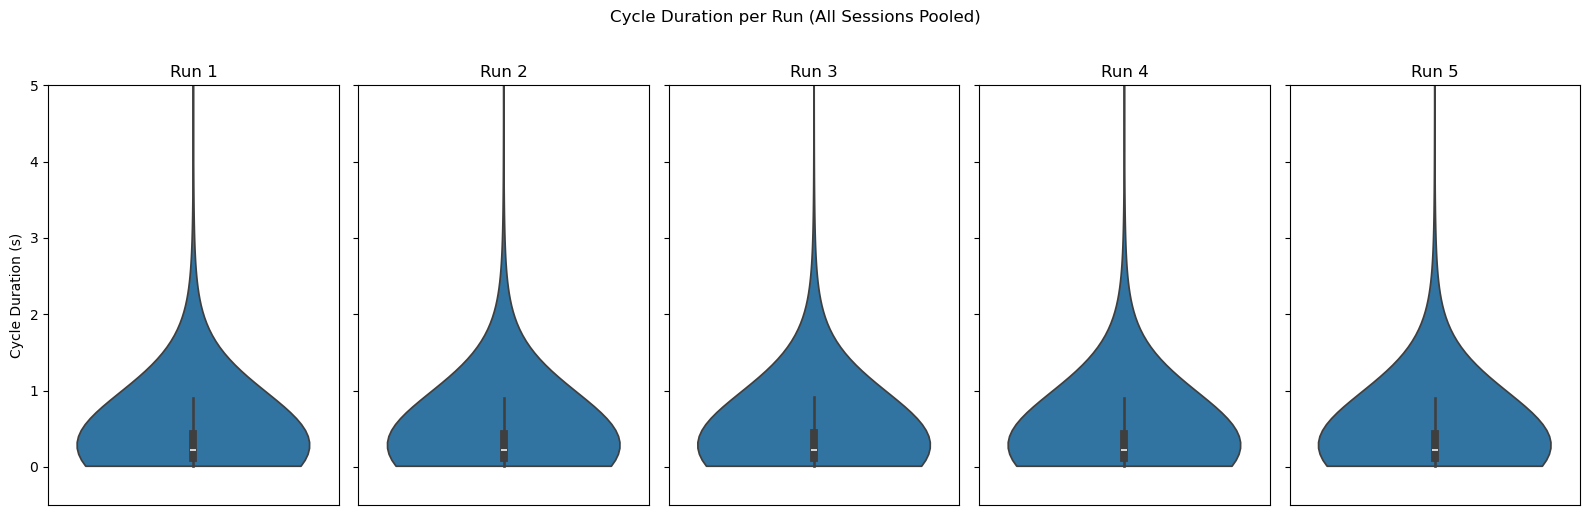

In [26]:
import glob, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/secondlevel_hmm"

def run_sort_key(path):
    # sort run10 after run2, and ignore the "(lowest_fe)" suffix
    name = os.path.basename(path.rstrip("/"))
    return int("".join(ch for ch in name if ch.isdigit()))

run_dirs = sorted(glob.glob(f"{base}/run*/"), key=run_sort_key)

all_cycle_duration_runs = {}
for i, d in enumerate(run_dirs, start=1):
    with open(f"{d}/cycle_duration.pkl", "rb") as fh:
        all_cycle_duration_runs[f"Run {i}"] = np.concatenate(pickle.load(fh))

fig, axes = plt.subplots(1, len(all_cycle_duration_runs), figsize=(16, 5), sharey=True)

for ax, (run_name, values) in zip(axes, all_cycle_duration_runs.items()):
    sns.violinplot(y=values, ax=ax, bw_adjust=15, cut=0)
    ax.set_title(run_name)
    ax.set_xlabel("")
    ax.set_xticks([])

axes[0].set_ylim(-0.5, 5)
axes[0].set_ylabel("Cycle Duration (s)")
fig.suptitle("Cycle Duration per Run (All Sessions Pooled)", y=1.02)
plt.tight_layout()
fig.savefig(f"{base}/cycle_duration_violins.png")
plt.show()

## Cycle strength

In [ ]:
import os
import numpy as np
from osl_dynamics.analysis.tinda import circle_angles, compute_cycle_strength

# Safety net: reload the best sequence
best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")
angleplot = circle_angles(best_sequence)

In [ ]:
# Reordered angle plot by best sequence; each cell = angular difference between two states
import seaborn as sns
import matplotlib.pyplot as plt

phase = np.angle(angleplot)
phase_reordered = phase[best_sequence][:, best_sequence]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    phase_reordered,
    cmap='RdBu_r',      # diverging colormap, good for angles
    center=0,           # centre colormap at 0
    annot=True,         # show values in cells
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Angle (rad)'},
    ax=ax,
    xticklabels=best_sequence + 1,
    yticklabels=best_sequence + 1,
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.tick_params(axis='y', rotation=0)
ax.set_title('Phase Heatmap (reordered by best sequence)', pad=15)
ax.set_xlabel('State')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

fig.savefig(f"{tinda_dir}/angleplot_viterbi.png")

In [ ]:
from osl_dynamics.analysis.tinda import tinda, circle_angles, compute_cycle_strength

# Safety net: reload viterbi stc and recompute the asymmetry matrix
stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]
fo_density, _, _ = tinda(stc)

mean_direction = np.squeeze(
    np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]) / fo_density.mean(axis=2), axis=-1)
)

mean_direction[np.isnan(mean_direction)] = 0

best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")
angleplot = circle_angles(best_sequence)

observed_cycle_strength = compute_cycle_strength(angleplot, mean_direction)
print(f"Observed cycle strength: {observed_cycle_strength:.4f}")

Observed cycle strength: 0.0154


/tmp/ipykernel_841871/3334409462.py:9: RuntimeWarning: Mean of empty slice
  np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]) / fo_density.mean(axis=2), axis=-1)


### Cycle strength per session

In [ ]:
from osl_dynamics.analysis.tinda import tinda, circle_angles, compute_cycle_strength

fo_density, _, _ = tinda(stc)                          # (K, K, 2, 1, n_sessions)

# Per-session FO asymmetry
asym = (fo_density[:, :, 0] - fo_density[:, :, 1]) / fo_density.mean(axis=2)  # (K, K, 1, n_sessions)
asym = asym[:, :, 0, :]                                # drop the singleton interval-range axis → (K, K, n_sessions)

angleplot = circle_angles(best_sequence)
cs_per_session = compute_cycle_strength(angleplot, asym, relative=True)       # (n_sessions,)
np.save(f"{tinda_dir}/cycle_strength_per_session.npy", cs_per_session)



## Permutation analysis

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from osl_dynamics.analysis.tinda import (
    tinda, optimise_sequence, circle_angles, compute_cycle_strength
)

# Paths
results_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states"
viterbi_dir = os.path.join(results_dir, "TINDA_viterbi")   # outputs go here too

# Load pre-saved outputs
# State time courses (VITERBI): load ALL sessions (arr_0, arr_1, ...)
stc_npz = np.load(os.path.join(viterbi_dir, "stc_viterbi_relabeled.npz"), allow_pickle=True)
stc = [stc_npz[key] for key in stc_npz.files]  # one array per session
print(f"Loaded {len(stc)} sessions from stc_viterbi.npz")

# Best sequence (pre-saved)
best_seq_path = os.path.join(viterbi_dir, "best_sequence_relabeled.npz.npy")
best_sequence = np.load(best_seq_path)
print(f"Loaded best sequence from {best_seq_path}")

# fo_density is not saved — recompute from stc
print("Computing fo_density from stc (observed data)...")
fo_density, _, _ = tinda(stc)

# Observed cycle strength
angleplot      = circle_angles(best_sequence)
mean_direction = np.squeeze(
    np.nanmean((fo_density[:, :, 0] - fo_density[:, :, 1]), axis=-1)
)
mean_direction[np.isnan(mean_direction)] = 0
observed_cycle_strength = compute_cycle_strength(angleplot, mean_direction)
print(f"Observed cycle strength: {observed_cycle_strength:.4f}")

# Permutation test setup
n_states   = stc[0].shape[1]
n_perms    = 1000
n_sessions = len(stc)

# Outputs
perms_path = os.path.join(viterbi_dir, "all_perms_viterbi.npy")
null_path  = os.path.join(viterbi_dir, "null_strengths_viterbi.npy")

# Pre-generate ALL shuffles once, deterministically
# Each shuffle is fixed and saved → resuming just indexes by i,
# so all_perms[770] is ALWAYS the same shuffle regardless of restarts.

if os.path.exists(perms_path):
    all_perms = np.load(perms_path)
    print(f"Loaded pre-generated shuffles: {all_perms.shape}")
else:
    rng = np.random.default_rng(42)
    all_perms = np.array([
        [rng.permutation(n_states) for _ in range(n_sessions)]
        for _ in range(n_perms)
    ])  # shape: (n_perms, n_sessions, n_states)
    np.save(perms_path, all_perms)
    print(f"Generated and saved shuffles: {all_perms.shape}")

# Load progress if a previous (crashed) run left results
# null_strengths is NaN-initialised so completed iterations are identifiable
if os.path.exists(null_path):
    null_strengths = np.load(null_path)
    if null_strengths.shape[0] != n_perms:
        raise ValueError(
            f"Existing null_strengths has length {null_strengths.shape[0]}, "
            f"expected {n_perms}. Delete it to start fresh."
        )
else:
    null_strengths = np.full(n_perms, np.nan)

n_done = int(np.sum(~np.isnan(null_strengths)))
if n_done == 0:
    print(f"Starting fresh: 0 / {n_perms} permutations")
else:
    print(f"Resuming from iteration {n_done} / {n_perms}")

# Main loop (resumes from n_done) 
for i in tqdm(range(n_done, n_perms), desc="Permutation test", ncols=80,
              initial=n_done, total=n_perms):
    # Use the PRE-GENERATED shuffle for this iteration (indexed by i)
    stc_shuffled = [s[:, all_perms[i, subj]] for subj, s in enumerate(stc)]

    # Full pipeline on shuffled data
    fo_density_p, _, _ = tinda(stc_shuffled)
    asym_p = np.squeeze(
        np.nanmean((fo_density_p[:, :, 0] - fo_density_p[:, :, 1]), axis=-1)
    )
    asym_p[np.isnan(asym_p)] = 0
    best_seq_p  = optimise_sequence(fo_density_p, n_perms=10**4)  # faster: 8! = 40320
    angleplot_p = circle_angles(best_seq_p)
    null_strengths[i] = compute_cycle_strength(angleplot_p, asym_p)

    # INCREMENTAL SAVE every 10 iterations 
    if (i + 1) % 10 == 0:
        np.save(null_path, null_strengths)

# Final save of the full null distribution
np.save(null_path, null_strengths)

# Results 
done = null_strengths[~np.isnan(null_strengths)]
p_value = np.mean(done >= observed_cycle_strength)
print(f"\nCompleted {done.shape[0]} / {n_perms} permutations")
print(f"Observed:  {observed_cycle_strength:.6f}")
print(f"Null mean: {done.mean():.6f}")
print(f"p-value:   {p_value:.10f}")

# Save scalar results
np.save(os.path.join(viterbi_dir, "observed_cycle_strength_viterbi.npy"), observed_cycle_strength)
np.save(os.path.join(viterbi_dir, "p_value_viterbi.npy"),                 p_value)
print(f"\nSaved: all_perms_viterbi.npy, null_strengths_viterbi.npy, "
      f"observed_cycle_strength_viterbi.npy, p_value_viterbi.npy")
print(f"    -> {viterbi_dir}")

# FIGURE 4: cyclical power + spectra composite #

In [ ]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from osl_dynamics.analysis import power


def cmap_hotcold(n=256):
    """Python port of utils/cmap_hotcold.m: diverging cyan -> black(0) -> yellow."""
    hot = plt.cm.hot(np.linspace(0, 1, n))    # black -> red -> yellow -> white
    cold = hot.copy()
    cold[:, 0] = hot[:, 2]                    # swap R <-> B  =>  black -> blue -> cyan
    cold[:, 2] = hot[:, 0]
    return ListedColormap(np.vstack([np.flipud(cold), hot]), name="hotcold")

if "hotcold" not in mpl.colormaps:
    mpl.colormaps.register(cmap_hotcold())

spectra_dir = "results/12_states/spectra"
maps_dir = "results/12_states/maps_hotcold"
wholemaps_dir = "results/12_states/whole_maps_hotcold"
os.makedirs(maps_dir, exist_ok=True)
os.makedirs(wholemaps_dir, exist_ok=True)

# Per-state power relative to the mean over states
psd = np.load(f"{spectra_dir}/psd.npy")     # (n_sub, n_states, n_parcels, n_freq)
w   = np.load(f"{spectra_dir}/w.npy")
f   = np.load(f"{spectra_dir}/f.npy")
gfo = np.load(f"{spectra_dir}/model_gfo.npy")

p = power.variance_from_spectra(f, psd)                       # (n_sub, n_states, n_parcels)
p -= np.average(p, axis=1, weights=gfo, keepdims=True)        # relative to mean over states
p_state = np.average(p, axis=0, weights=w)                    # (n_states, n_parcels)

# 1. Save the single left-lateral view
power.save(
    p_state,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    subtract_mean=False,
    filename=f"{maps_dir}/state.png",
    plot_kwargs={
        "cmap": "hotcold",
        "symmetric_cbar": True,
        "hemispheres": ["left"],
        "views": ["lateral"],
        "cbar_fontsize": 16,          
        "cbar_tick_format": "%.2g",
    },
)
print("Saved hotcold left-lateral per-state maps ->", maps_dir)

# 2. Save the full whole-brain four views (left/right, lateral/medial)
power.save(
    p_state,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    subtract_mean=False,
    filename=f"{wholemaps_dir}/state.png",
    plot_kwargs={
        "cmap": "hotcold",
        "symmetric_cbar": True,
        "hemispheres": ["left", "right"],
        "views": ["lateral", "medial"],
        "cbar_fontsize": 16,
        "cbar_tick_format": "%.2g",
    },
)
print("Saved hotcold whole-brain per-state maps ->", wholemaps_dir)


Saving images:   0%|          | 0/12 [00:00<?, ?it/s]

Saved hotcold left-lateral per-state maps -> results/12_states/maps_hotcold


Saving images:   0%|          | 0/12 [00:00<?, ?it/s]

Saved hotcold whole-brain per-state maps -> results/12_states/whole_maps_hotcold


Saved composite -> results/12_states/TINDA_viterbi/figure4_cycle_composite.png


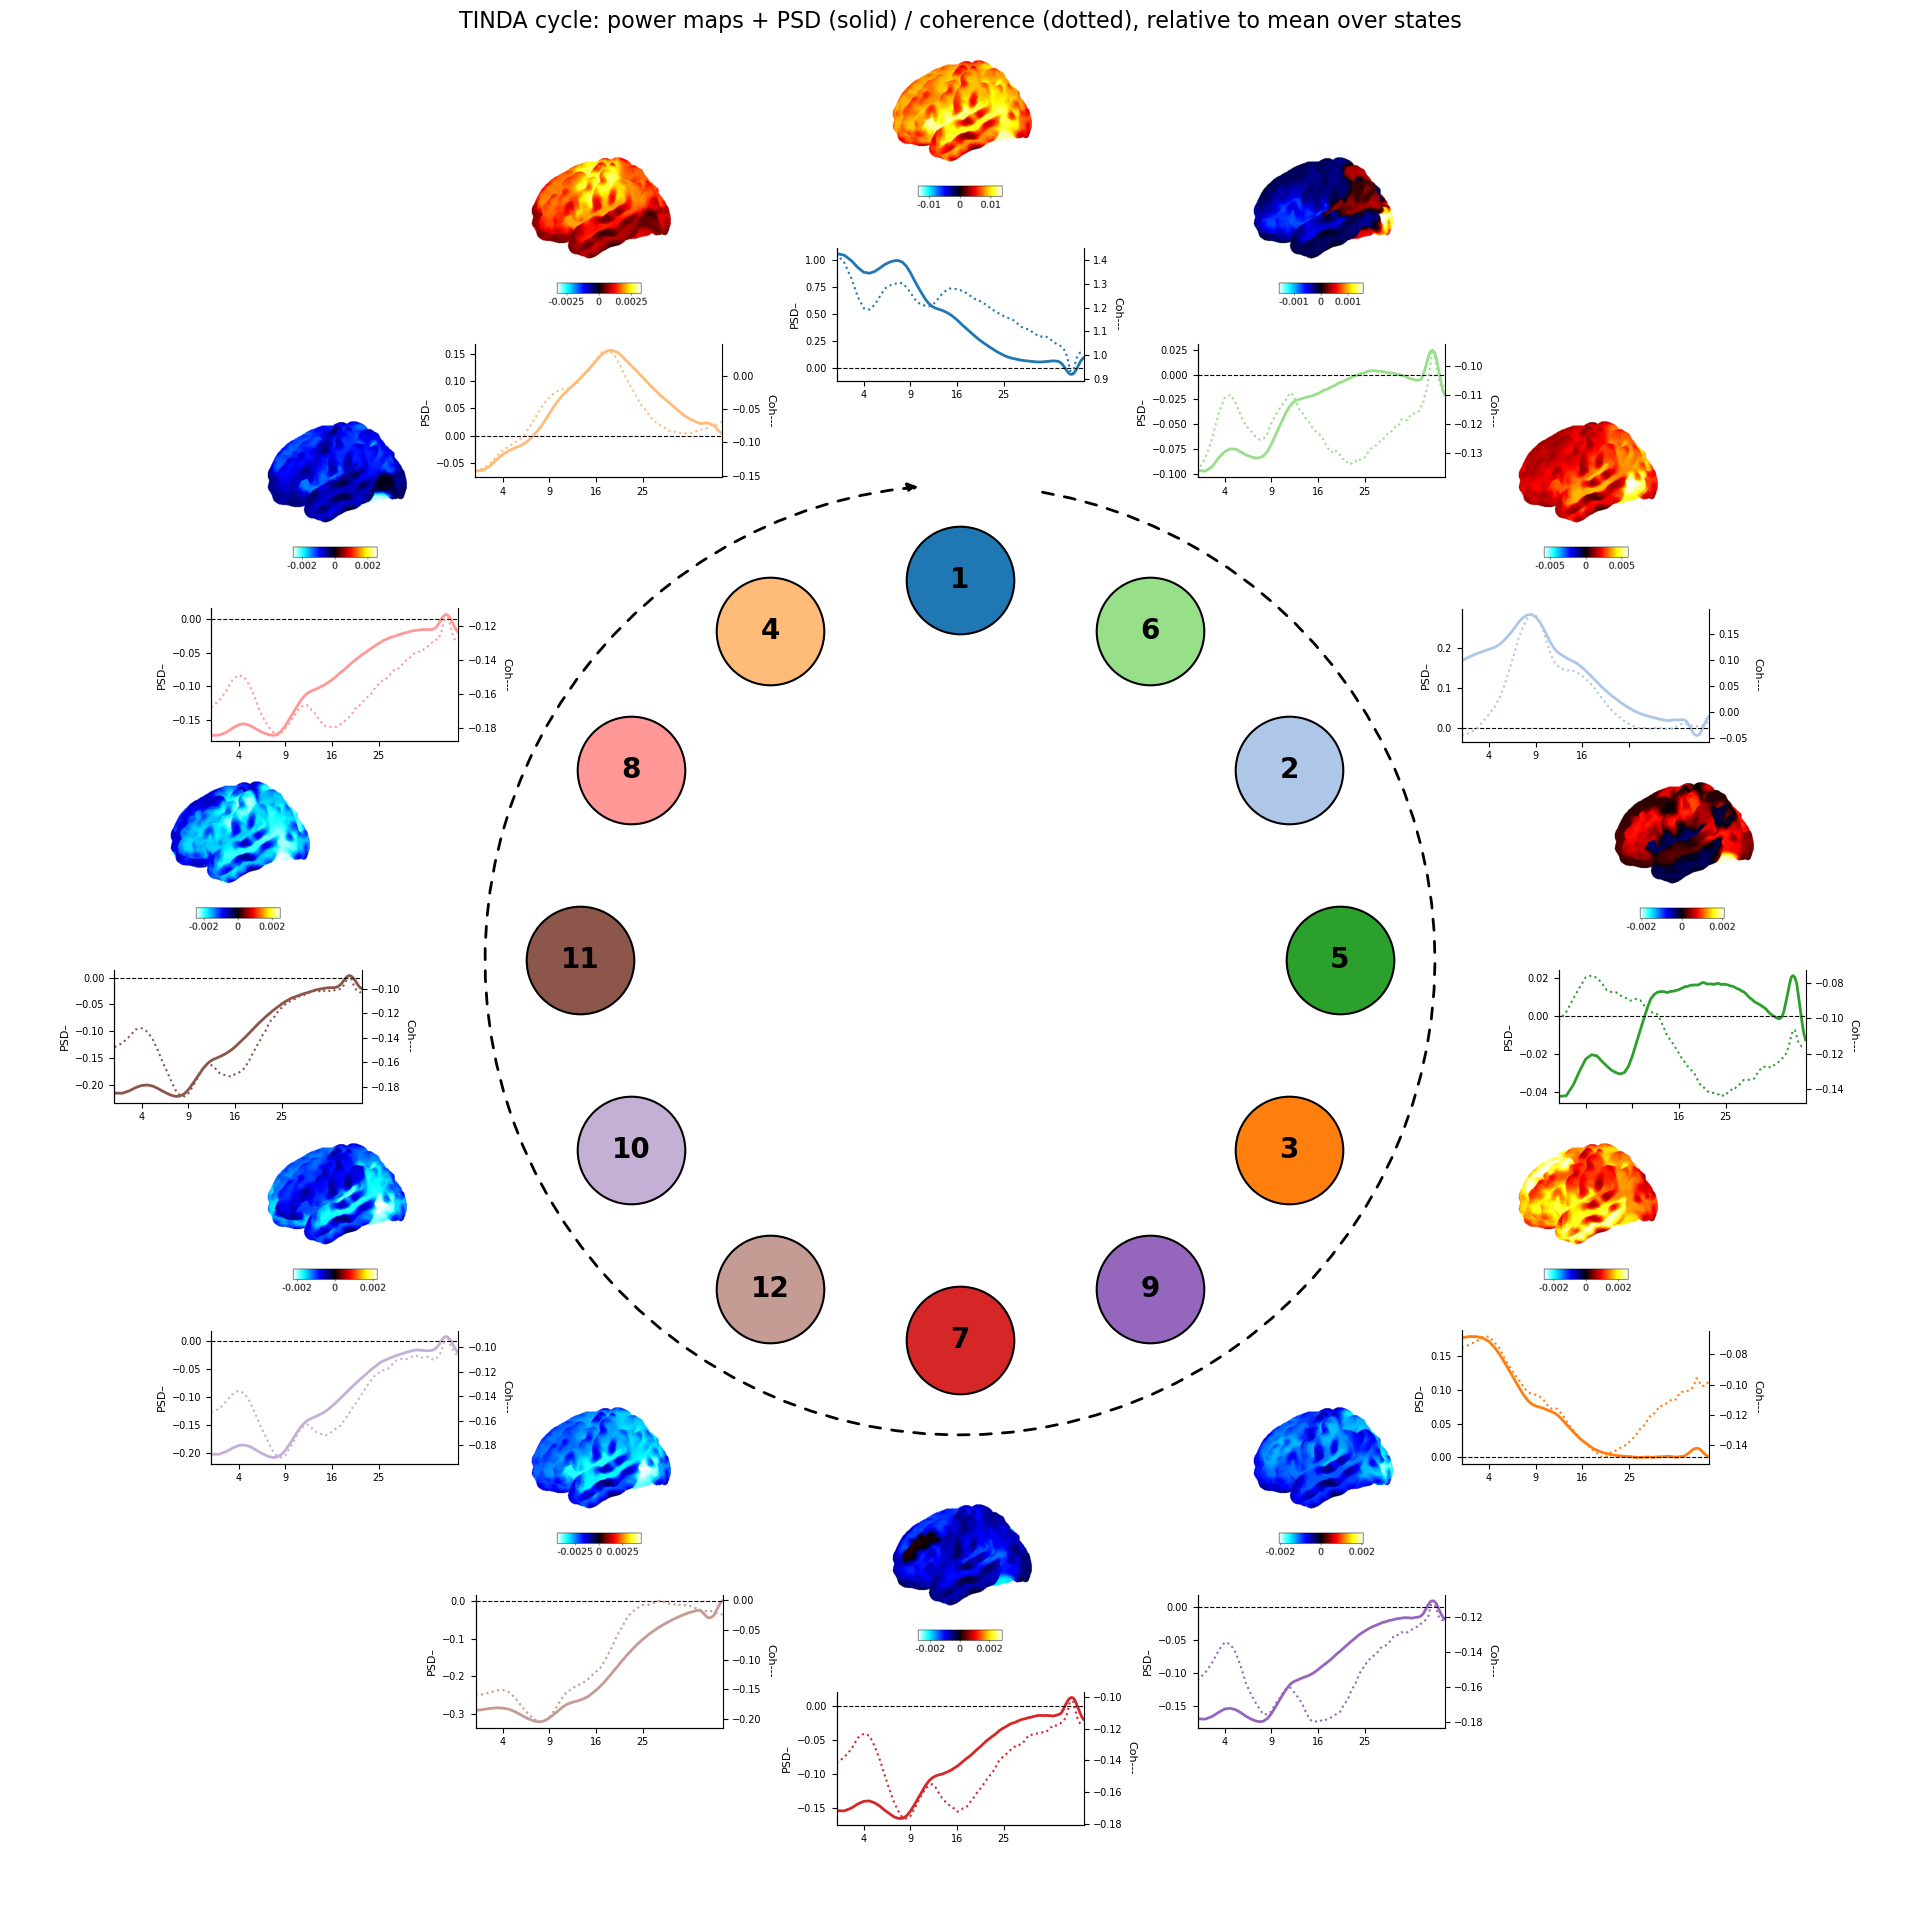

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import numpy as np

spectra_dir = "results/12_states/spectra"
tinda_dir   = "results/12_states/TINDA_viterbi"
maps_dir    = "results/12_states/maps_hotcold"

# Cycle order
# Rotate the cycle so state 1 (index 0) sits at the 12 o'clock slot,
# keeping the clockwise order intact.
start = int(np.where(best_sequence == 0)[0][0])
best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")
best_seq_rev = np.roll(best_sequence[::-1], 1)

# Relative PSD and coherence per state (group-averaged, weighted) 
psd = np.load(f"{spectra_dir}/psd.npy")     # (n_sub, n_states, n_parcels, n_freq)
coh = np.load(f"{spectra_dir}/coh.npy")     # (n_sub, n_states, n_parcels, n_parcels, n_freq)
w   = np.load(f"{spectra_dir}/w.npy")
f   = np.load(f"{spectra_dir}/f.npy")
n_states = psd.shape[1]

gpsd = np.average(psd, axis=0, weights=w)               # (n_states, n_parcels, n_freq)
psd_state = gpsd.mean(axis=1)                           # (n_states, n_freq)
rel_psd = psd_state / psd_state.mean(axis=0) - 1        # relative to mean over states

gcoh = np.average(coh, axis=0, weights=w)               # (n_states, n_parcels, n_parcels, n_freq)
iu = np.triu_indices(gcoh.shape[1], k=1)
coh_state = gcoh[:, iu[0], iu[1], :].mean(axis=1)       # (n_states, n_freq), mean over parcel pairs
rel_coh = coh_state / coh_state.mean(axis=0) - 1

# Per-state colours (consistent between nodes and insets) 
state_colors = cm.tab20(np.linspace(0, 1, 20))[:n_states]

# Geometry: slot i (clockwise from top) holds state best_sequence[i] 
ang = np.pi / 2 - np.arange(n_states) * 2 * np.pi / n_states
cx, cy = 0.5, 0.5            # figure-fraction centre
R_node, R_ring, R_block = 0.2, 0.25, 0.38

sqrt_f = np.sqrt(f)
xticks = np.sqrt([4, 9, 16, 25])

fig = plt.figure(figsize=(19, 19))
axc = fig.add_axes([0, 0, 1, 1])
axc.set_xlim(0, 1); axc.set_ylim(0, 1)
axc.set_aspect("equal"); axc.axis("off")

theta = np.linspace(np.radians(80), np.radians(-265), 100)
x_arc = cx + R_ring * np.cos(theta)
y_arc = cy + R_ring * np.sin(theta)
verts = np.column_stack((x_arc, y_arc))
codes = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 1)

# Add the dashed arrow patch instead of the full Circle
axc.add_patch(
    FancyArrowPatch(
        path=Path(verts, codes),
        arrowstyle="-|>",      # Solid arrow head style
        mutation_scale=15,     # Adjust this number to change arrow head size
        linestyle=(0, (4, 4)), # Same dashed pattern you had
        lw=2,
        color="k",
        zorder=0               # Keeps it in the background like the original circle
    )
)

# Numbered, coloured nodes around the cycle (just inside the dashed ring)
for i in range(n_states):
    s = int(best_seq_rev[i])
    nx, ny = cx + R_node * np.cos(ang[i]), cy + R_node * np.sin(ang[i])
    axc.scatter([nx], [ny], s=6000, color=state_colors[s], edgecolor="k", lw=1.5, zorder=5)
    axc.text(nx, ny, str(s + 1), ha="center", va="center",
             fontsize=20, fontweight="bold", zorder=6)

# Brain map + PSD/coherence inset per slot (outside the ring)
for i in range(n_states):
    s = int(best_seq_rev[i])
    bx, by = cx + R_block * np.cos(ang[i]), cy + R_block * np.sin(ang[i])

    # brain map (single left-lateral view + colorbar below), placed on top of the block
    img_path = f"{maps_dir}/state{s:02d}.png"
    if os.path.exists(img_path):
        axb = fig.add_axes([bx - 0.075, by + 0.0, 0.15, 0.11])
        axb.imshow(mpimg.imread(img_path)); axb.axis("off")
    else:
        print("Missing map (run the colormap cell first):", img_path)

    # PSD (left axis, solid) + coherence (right axis, dotted), state colour, sqrt-f axis
    axp = fig.add_axes([bx - 0.065, by - 0.075, 0.13, 0.07])
    axp.plot(sqrt_f, rel_psd[s], color=state_colors[s], lw=2)
    axp.axhline(0, color="k", ls="--", lw=0.8)
    axp.set_xticks(xticks); axp.set_xticklabels([4, 9, 16, 25], fontsize=7)
    axp.tick_params(axis="y", labelsize=7)
    axp.set_xlim(sqrt_f[0], sqrt_f[-1])
    axp.set_ylabel("PSD–", fontsize=8)
    for sp in ["top", "right"]:
        axp.spines[sp].set_visible(False)

    axco = axp.twinx()
    axco.plot(sqrt_f, rel_coh[s], color=state_colors[s], lw=1.5, ls=":")
    axco.tick_params(axis="y", labelsize=7)
    axco.set_ylabel("Coh---", fontsize=8, rotation=270, labelpad=10)
    axco.spines["top"].set_visible(False)

fig.suptitle("TINDA cycle: power maps + PSD (solid) / coherence (dotted), relative to mean over states",
             fontsize=16, y=1)

out = f"{tinda_dir}/figure4_cycle_composite.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print("Saved composite ->", out)
plt.show()

# FIGURE 3: cycle strength by interval-time bin #

In [ ]:
import warnings
import numpy as np
from osl_dynamics.analysis.tinda import tinda, circle_angles, compute_cycle_strength

warnings.filterwarnings("ignore")  # silence 0/0 in the FO-asymmetry normalisation (-> NaN, handled by nansum)

tinda_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi"
fs = 250
percentiles = np.arange(0, 101, 20).astype(float)   # [0,20,40,60,80,100] -> 5 quintile bins
n_bins_q = len(percentiles) - 1

# Safety net: reload viterbi state time courses + group best sequence
stc_npz = np.load(f"{tinda_dir}/stc_viterbi_relabeled.npz.npy", allow_pickle=True)
stc = [stc_npz[f"arr_{i}"] for i in range(len(stc_npz.files))]
best_sequence = np.load(f"{tinda_dir}/best_sequence_viterbi.npy")
K = stc[0].shape[1]
n_sessions = len(stc)
angleplot = circle_angles(best_sequence)


def cycle_strength_per_bin(fo_density, ap):
    """Per-session cycle strength for each interval bin.

    fo_density: (K, K, 2, n_bins, n_sessions) from tinda(..., interval_range=...).
    Returns (n_sessions, n_bins), normalised to the theoretical maximum (a.u.).
    """
    n_bins = fo_density.shape[3]
    out = np.zeros((fo_density.shape[4], n_bins))
    for q in range(n_bins):
        fq = fo_density[:, :, :, q, :]                       # (K, K, 2, n_sessions)
        asym = (fq[:, :, 0, :] - fq[:, :, 1, :]) / fq.mean(axis=2)  
        out[:, q] = compute_cycle_strength(ap, asym, relative=True)  # (n_sessions,)
    return out


# Observed: binned TINDA (percentile interval bins, per session/state)
print(f"Running binned TINDA over {n_sessions} sessions (~15 s)...")
fo_density, fo_sum, stats = tinda(
    stc, n_bins=2, interval_mode="perc", interval_range=percentiles
)
# fo_density: (K, K, 2, n_bins, n_sessions)

# Panel b data: cycle strength per session per bin
cs = cycle_strength_per_bin(fo_density, angleplot)           # (n_sessions, 5)

# Panel a data: mean interval time (s) per session per bin, pooled over states

IT = np.full((n_sessions, n_bins_q), np.nan)
for s in range(n_sessions):
    for q in range(n_bins_q):
        per_state = []
        for k in range(K):
            dur = np.asarray(stats[s][k]["durations"], float)
            if dur.size == 0:
                continue
            lo, hi = np.percentile(dur, percentiles[q]), np.percentile(dur, percentiles[q + 1])
            sel = dur[(dur >= lo) & (dur <= hi)]     
            if sel.size:
                per_state.append(sel.mean())
        if per_state:
            IT[s, q] = np.nanmean(per_state) / fs    # seconds

np.save(f"{tinda_dir}/cycle_strength_quintile.npy", cs)
np.save(f"{tinda_dir}/interval_time_quintile.npy", IT)
np.save(f"{tinda_dir}/fo_density_quintile.npy", fo_density)   # (K,K,2,n_bins,n_sessions) for panel c

print("Mean cycle strength per bin (a.u.):", np.round(np.nanmean(cs, 0), 4))
print("Mean interval time per bin (s):    ", np.round(np.nanmean(IT, 0), 4))

In [ ]:
# RUN IN A SEPARATE SCRIPT FOR SCREEN

import os
import numpy as np
from tqdm import tqdm
from osl_dynamics.analysis.tinda import (
    tinda, optimise_sequence, circle_angles, compute_cycle_strength
)

# Paths
results_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states"
viterbi_dir = os.path.join(results_dir, "TINDA_viterbi")
os.makedirs(viterbi_dir, exist_ok=True)

# Load viterbi state time courses
stc_npz = np.load(os.path.join(viterbi_dir, "stc_viterbi_relabeled.npz"), allow_pickle=True)
stc = [stc_npz[key] for key in stc_npz.files]  # one array per session
print(f"Loaded {len(stc)} sessions from stc_viterbi.npz")

# Observed per-bin cycle strength
cs_path = os.path.join(viterbi_dir, "cycle_strength_quintile.npy")
if not os.path.exists(cs_path):
    raise FileNotFoundError(
        "Run the observed 'FIGURE 3' cell first - it saves cycle_strength_quintile.npy."
    )
cs_obs   = np.load(cs_path)             # (n_sessions, n_bins)
observed = np.nanmean(cs_obs, axis=0)   # (n_bins,)

# Permutation test setup
percentiles = np.arange(0, 101, 20).astype(float)   # 5 quintile bins
n_bins_q   = len(percentiles) - 1
n_states   = stc[0].shape[1]
n_perms    = 1000
n_sessions = len(stc)

perms_path = os.path.join(viterbi_dir, "all_perms_viterbi.npy")          # shared shuffle set
null_path  = os.path.join(viterbi_dir, "null_strengths_quintile.npy")    # (n_perms, n_bins)

# SOLUTION 3: pre-generate ALL shuffles once, deterministically
# Reuses the SAME all_perms_viterbi.npy as the main permutation test, so all_perms[770]
# is ALWAYS the same shuffle regardless of restarts (and consistent across both tests).
if os.path.exists(perms_path):
    all_perms = np.load(perms_path)
    print(f"Loaded pre-generated shuffles: {all_perms.shape}")
else:
    rng = np.random.default_rng(42)
    all_perms = np.array([
        [rng.permutation(n_states) for _ in range(n_sessions)]
        for _ in range(n_perms)
    ])  # shape: (n_perms, n_sessions, n_states)
    np.save(perms_path, all_perms)
    print(f"Generated and saved shuffles: {all_perms.shape}")

# RESUME: load progress if a previous (crashed) run left results
# null_strengths is NaN-initialised so completed iterations are identifiable.
if os.path.exists(null_path):
    null_strengths = np.load(null_path)
    if null_strengths.shape != (n_perms, n_bins_q):
        raise ValueError(
            f"Existing null_strengths has shape {null_strengths.shape}, "
            f"expected {(n_perms, n_bins_q)}. Delete it to start fresh."
        )
else:
    null_strengths = np.full((n_perms, n_bins_q), np.nan)

n_done = int(np.sum(~np.isnan(null_strengths[:, 0])))
if n_done == 0:
    print(f"Starting fresh: 0 / {n_perms} permutations")
else:
    print(f"Resuming from iteration {n_done} / {n_perms}")

# Main loop (resumes from n_done)
# NOTE: each permutation runs a full binned TINDA (~15 s), so 1000 perms takes a few hours.
for i in tqdm(range(n_done, n_perms), desc="Quintile permutation test", ncols=80,
              initial=n_done, total=n_perms):
    # Use the PRE-GENERATED shuffle for this iteration (indexed by i)
    stc_shuffled = [s[:, all_perms[i, subj]] for subj, s in enumerate(stc)]

    # Binned TINDA on the shuffled data (percentile interval bins, per session/state)
    fo_density_p, _, _ = tinda(
        stc_shuffled, n_bins=2, interval_mode="perc", interval_range=percentiles
    )

    # Best sequence for the permuted data (collapse bins -> all-interval FO)
    best_seq_p  = optimise_sequence(fo_density_p.mean(axis=3), n_perms=10**4)
    angleplot_p = circle_angles(best_seq_p)

    # Per-bin cycle strength, averaged over sessions
    for q in range(n_bins_q):
        fq = fo_density_p[:, :, :, q, :]
        asym = (fq[:, :, 0, :] - fq[:, :, 1, :]) / fq.mean(axis=2)
        null_strengths[i, q] = np.nanmean(compute_cycle_strength(angleplot_p, asym, relative=True))

    # INCREMENTAL SAVE every 10 iterations
    if (i + 1) % 10 == 0:
        np.save(null_path, null_strengths)

# Final save of the full null distribution
np.save(null_path, null_strengths)

# Results: one-sided p-values, Bonferroni-corrected over the 5 bins
done = null_strengths[~np.isnan(null_strengths[:, 0])]
pvals      = np.array([np.mean(done[:, q] >= observed[q]) for q in range(n_bins_q)])
pvals_bonf = np.minimum(pvals * n_bins_q, 1.0)
np.save(os.path.join(viterbi_dir, "pvalue_quintile.npy"), pvals_bonf)

print(f"\nCompleted {done.shape[0]} / {n_perms} permutations")
for q in range(n_bins_q):
    print(f"  bin {q+1}: S={observed[q]:.4f}  null_mean={done[:, q].mean():.4f}  "
          f"p={pvals[q]:.4f}  p_bonf={pvals_bonf[q]:.4f}")
print(f"\nSaved: null_strengths_quintile.npy, pvalue_quintile.npy -> {viterbi_dir}")

Significance from 1000 completed permutations.
Saved -> /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/figure3_quintile_cycle_strength.png


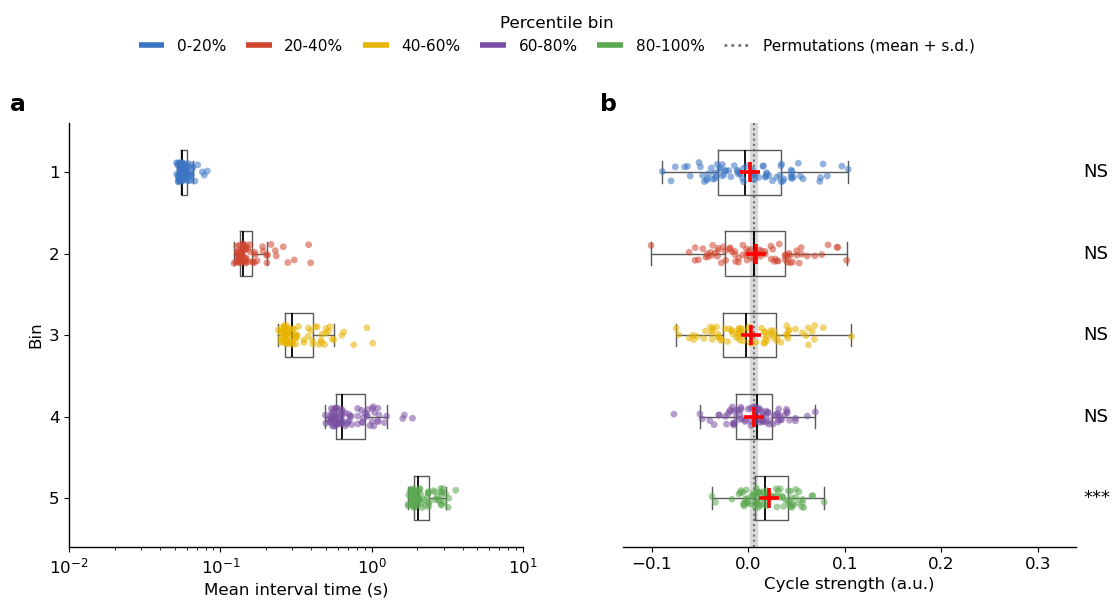

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

tinda_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi"

# Prerequisite: the observed "FIGURE 3" cell must have been run (it saves these).
if not os.path.exists(f"{tinda_dir}/cycle_strength_quintile.npy"):
    raise FileNotFoundError(
        "Run the observed 'FIGURE 3' cell first - it computes and saves "
        "cycle_strength_quintile.npy / interval_time_quintile.npy / fo_density_quintile.npy."
    )

cs = np.load(f"{tinda_dir}/cycle_strength_quintile.npy")    # (n_sessions, 5)
IT = np.load(f"{tinda_dir}/interval_time_quintile.npy")     # (n_sessions, 5)

# Permutation null is optional (that cell takes hours). If present - even a PARTIAL run -
# significance is computed on the fly from the completed permutations, so the NS / * / ** / ***
# labels show without waiting for the final pvalue_quintile.npy.
null_path = f"{tinda_dir}/null_strengths_quintile.npy"
has_perm = os.path.exists(null_path)
if has_perm:
    null = np.load(null_path)                       # (n_perms, 5), NaN where not yet run
    done = null[~np.isnan(null[:, 0])]              # completed permutations
    has_perm = done.shape[0] > 0
if has_perm:
    obs = np.nanmean(cs, axis=0)
    nb_q = cs.shape[1]
    pvals = np.array([np.mean(done[:, q] >= obs[q]) for q in range(nb_q)])
    pvals_bonf = np.minimum(pvals * nb_q, 1.0)      # Bonferroni over the 5 bins
    print(f"Significance from {done.shape[0]} completed permutations.")
else:
    print("No permutation results yet - plotting a + b without the null band / asterisks.")

n_bins_q = cs.shape[1]
bins = np.arange(1, n_bins_q + 1)
bin_colors = ["#3b75c4", "#d1462f", "#e7b400", "#7a4fa3", "#5aa84f"]
bin_labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

plt.rcParams.update({"font.size": 12, "axes.linewidth": 1.0,
                     "font.family": "sans-serif", "svg.fonttype": "none"})


def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "NS"


rng = np.random.default_rng(0)
def jitter(n, scale=0.12):
    return (rng.random(n) - 0.5) * 2 * scale


def box_scatter(ax, vals, y, color):
    ax.boxplot(vals, positions=[y], vert=False, widths=0.55, showfliers=False,
               medianprops=dict(color="k", lw=1.3),
               whiskerprops=dict(color="0.35", lw=1), capprops=dict(color="0.35", lw=1),
               boxprops=dict(color="0.35", lw=1))
    ax.scatter(vals, np.full(vals.size, y) + jitter(vals.size), s=24, color=color,
               alpha=0.55, edgecolor="none", zorder=3)


fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"wspace": 0.22})

# Panel a: mean interval time per bin (log x)
for i in range(n_bins_q):
    v = IT[~np.isnan(IT[:, i]), i]
    box_scatter(axa, v, bins[i], bin_colors[i])
axa.set_xscale("log")
axa.set_xlim(1e-2, 1e1)
axa.set_xlabel("Mean interval time (s)")
axa.set_ylabel("Bin")
axa.set_yticks(bins); axa.set_ylim(0.4, n_bins_q + 0.6); axa.invert_yaxis()
axa.spines[["top", "right"]].set_visible(False)
axa.text(-0.13, 1.03, "a", transform=axa.transAxes, fontsize=17, fontweight="bold")

# Panel b: cycle strength per bin + permutation null band + red-+ means
if has_perm:
    m_all = float(np.nanmean(null))
    sd_all = float(np.nanmean(np.nanstd(null, axis=0)))
    axb.axvspan(m_all - sd_all, m_all + sd_all, color="0.85", zorder=0)     # null mean +/- s.d.
    axb.axvline(m_all, color="0.45", ls=(0, (1, 1.5)), lw=1.5, zorder=1)    # dotted: permutation mean
for i in range(n_bins_q):
    v = cs[~np.isnan(cs[:, i]), i]
    box_scatter(axb, v, bins[i], bin_colors[i])
    axb.plot([np.mean(v)], [bins[i]], marker="+", color="red", ms=15, mew=2.6, zorder=6)
    if has_perm:
        # place the label just outside the right spine (axes-fraction x) so it is never clipped
        axb.annotate(stars(pvals_bonf[i]), xy=(1.015, bins[i]),
                     xycoords=("axes fraction", "data"), va="center", ha="left",
                     fontsize=13, annotation_clip=False)
axb.set_xlim(-0.13, 0.34)
axb.set_xlabel("Cycle strength (a.u.)")
axb.set_yticks(bins); axb.set_ylim(0.4, n_bins_q + 0.6); axb.invert_yaxis()
axb.set_yticklabels([])
axb.spines[["top", "right", "left"]].set_visible(False)
axb.tick_params(left=False)
axb.text(-0.05, 1.03, "b", transform=axb.transAxes, fontsize=17, fontweight="bold")

# top legend (Nature style)
handles = [Line2D([0], [0], color=c, lw=4, solid_capstyle="butt", label=l)
           for c, l in zip(bin_colors, bin_labels)]
handles.append(Line2D([0], [0], color="0.45", lw=2, ls=(0, (1, 1.5)),
                      label="Permutations (mean + s.d.)"))
leg = fig.legend(handles=handles, ncol=6, loc="upper center", frameon=False,
                 bbox_to_anchor=(0.5, 1.10), title="Percentile bin",
                 columnspacing=1.3, handlelength=1.7, fontsize=11)
leg.get_title().set_fontsize(12)

fig.savefig(f"{tinda_dir}/figure3_quintile_cycle_strength.png", dpi=200, bbox_inches="tight")
print("Saved ->", f"{tinda_dir}/figure3_quintile_cycle_strength.png")
plt.show()

## Figure 3c: per-bin cycle plots (arrows = significant FO asymmetries)

/tmp/ipykernel_969289/842272530.py:34: RuntimeWarning: Mean of empty slice
  mean_dir = np.nanmean(f0 - f1, axis=-1)
/tmp/ipykernel_969289/842272530.py:39: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, pvals = ttest_rel(f0, f1, axis=-1, nan_policy="omit")


Bin 1: 0 significant FO asymmetries (p < 0.05)
Bin 2: 0 significant FO asymmetries (p < 0.05)
Bin 3: 0 significant FO asymmetries (p < 0.05)
Bin 4: 0 significant FO asymmetries (p < 0.05)
Bin 5: 7 significant FO asymmetries (p < 0.05)
Saved -> /ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi/figure3c_bin_cycles_vertical.png


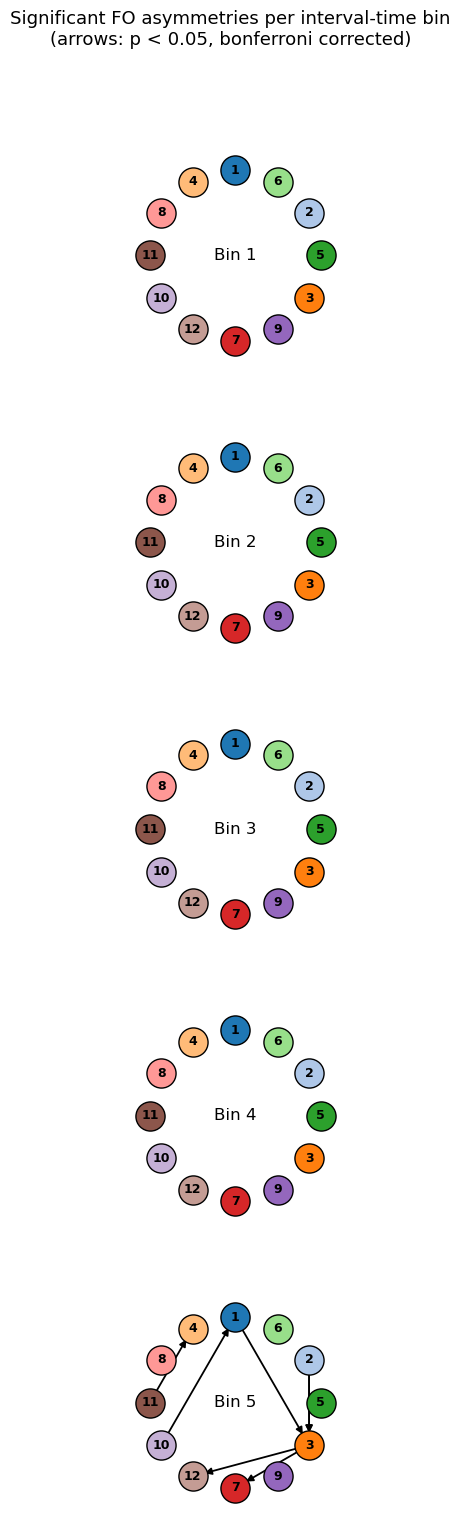

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

tinda_dir = "/ohba/pi/mwoolrich/mricofernándezsansilvestre/masters/rob_data/results/12_states/TINDA_viterbi"
if not os.path.exists(f"{tinda_dir}/fo_density_quintile.npy"):
    raise FileNotFoundError(
        "Run the observed 'FIGURE 3' cell first - it saves fo_density_quintile.npy."
    )
fo_density = np.load(f"{tinda_dir}/fo_density_quintile.npy")     # (K, K, 2, n_bins, n_sessions)
best_sequence = np.load(f"{tinda_dir}/best_sequence_relabeled.npz.npy")
best_seq_rev = np.roll(best_sequence[::-1], 1)
K = fo_density.shape[0]
n_bins_q = fo_density.shape[3]
alpha_sig = 0.05
# Multiple-comparison correction over the K*(K-1) edges per bin.
# Use "none" for the raw p<0.05 version (much busier at high N),
# or "fdr" for Benjamini-Hochberg.
correction = "bonferroni"   # "bonferroni" | "fdr" | "none"

state_colors = cm.tab20(np.linspace(0, 1, 20))[:K]

# perfect-circle node positions: slot i (clockwise from top) holds state best_sequence[i]
ang = np.pi / 2 - np.arange(K) * 2 * np.pi / K
node_xy = {int(best_seq_rev[i]): (np.cos(ang[i]), np.sin(ang[i])) for i in range(K)}


def draw_bin_cycle(ax, q):
    f0 = fo_density[:, :, 0, q, :]            # first half, (K, K, n_sessions)
    f1 = fo_density[:, :, 1, q, :]            # second half
    mean_dir = np.nanmean(f0 - f1, axis=-1)
    mean_dir[np.isnan(mean_dir)] = 0

    # paired t-test across sessions for each state pair
    with np.errstate(all="ignore"):
        _, pvals = ttest_rel(f0, f1, axis=-1, nan_policy="omit")
    pvals = np.asarray(pvals, dtype=float)
    pvals[np.isnan(pvals)] = 1.0

    # significance with multiple-comparison correction over off-diagonal edges
    sig = np.zeros((K, K), dtype=bool)
    off = ~np.eye(K, dtype=bool)
    pflat = pvals[off]
    if correction == "bonferroni":
        sigflat = pflat < alpha_sig / pflat.size
    elif correction == "fdr":
        sigflat = multipletests(pflat, alpha=alpha_sig, method="fdr_bh")[0]
    else:
        sigflat = pflat < alpha_sig
    sig[off] = sigflat

    # arrows for significant edges, oriented by sign of the mean asymmetry
    n_arrows = 0
    for a in range(K):
        for b in range(K):
            if sig[a, b]:
                src, dst = (a, b) if mean_dir[a, b] > 0 else (b, a)
                ax.annotate("", xy=node_xy[dst], xytext=node_xy[src],
                            arrowprops=dict(arrowstyle="-|>", color="k", lw=1.3,
                                            shrinkA=9, shrinkB=9))
                n_arrows += 1

    # nodes
    for s, (x, y) in node_xy.items():
        ax.scatter([x], [y], s=440, color=state_colors[s], edgecolor="k", lw=1, zorder=5)
        ax.text(x, y, str(s + 1), ha="center", va="center", fontsize=9,
                fontweight="bold", zorder=6)
    ax.text(0, 0, f"Bin {q + 1}", ha="center", va="center", fontsize=12)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal"); ax.axis("off")
    return n_arrows

fig, axes = plt.subplots(n_bins_q, 1, figsize=(4, 3.6 * n_bins_q))
for q, ax in enumerate(np.atleast_1d(axes)):
    na = draw_bin_cycle(ax, q)
    print(f"Bin {q + 1}: {na} significant FO asymmetries (p < {alpha_sig})")

fig.suptitle(f"Significant FO asymmetries per interval-time bin\n"
             f"(arrows: p < {alpha_sig}, {correction} corrected)", y=0.95, fontsize=13)
fig.savefig(f"{tinda_dir}/figure3c_bin_cycles_vertical.png", dpi=200, bbox_inches="tight")
print("Saved ->", f"{tinda_dir}/figure3c_bin_cycles_vertical.png")
plt.show()
